# Breast Cancer Classification using Logistic Regression
---
This Jupyter Notebook walks through the implementation of a **Logistic Regression** pipeline to classify breast cancer tumors as either **Malignant (M)** or **Benign (B)** using the Breast Cancer Wisconsin Diagnostic dataset.

### Pipeline Workflow
1. **Load Dataset**: Read data from `dataset/data.csv`.
2. **Explore Dataset**: Generate summary statistics and identify distributions.
3. **Data Cleaning & Preprocessing**: Drop unnecessary fields, handle missing values, and encode categorical targets.
4. **Train-Test Split**: Partition the dataset stratifying by the target class to ensure balanced split.
5. **Feature Standardization**: Scaler fitting and transforming to prevent data scale bias.
6. **Train Logistic Regression Model**: Fit the classifier model.
7. **Predict & Evaluate**: Estimate probabilities, classes, and calculate performance metrics (Accuracy, ROC-AUC, F1-Score).
8. **Model Interpretation**: Identify feature importances using standardized model coefficients.
9. **Save Outputs**: Save predictions, metrics report, and the trained model pipeline.


## Step 1: Environment Setup & Library Imports
First, we import the necessary scientific computing, plotting, and machine learning modules from `scikit-learn`.


In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, accuracy_score, precision_score, recall_score, f1_score
)

# Set plot design parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
    'figure.figsize': (8, 5)
})
PRIMARY_COLOR = '#1e3d59'
SECONDARY_COLOR = '#ff6e40'
ACCENT_COLOR = '#ffc13b'
print("Libraries successfully imported!")


Libraries successfully imported!


## Step 2: Load and Clean Dataset
We read the Breast Cancer dataset from `../dataset/data.csv`. We will:
- Strip whitespace from column headers.
- Drop any completely null or unnamed columns (often created by trailing commas).
- Encode the `diagnosis` column: Malignant (M) -> 1, Benign (B) -> 0.


In [2]:
# Load data.csv (note the path relative to this notebooks/ directory is ../dataset/data.csv)
df = pd.read_csv('../dataset/data.csv')

# Strip white spaces and clean empty columns
df.columns = df.columns.str.strip()
df = df.dropna(axis=1, how='all')
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed:')])

print(f"Loaded dataset with shape: {df.shape}")
df.head()


Loaded dataset with shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3: Exploratory Data Analysis (EDA)
Let's visualize the target class distribution to see if we have an imbalanced dataset, and display a correlation heatmap for the main columns (`_mean` variables).


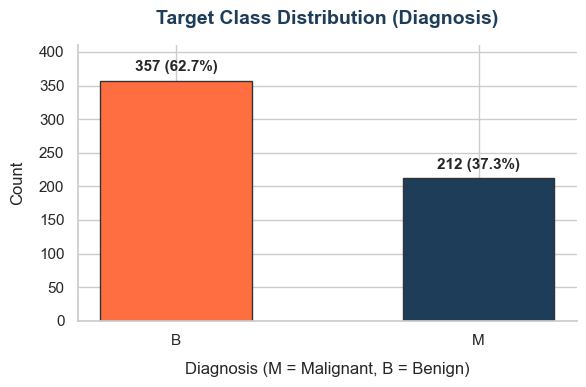

In [3]:
# 1. Diagnosis Class Distribution
plt.figure(figsize=(6, 4))
counts = df['diagnosis'].value_counts()
bars = plt.bar(counts.index, counts.values, color=[SECONDARY_COLOR, PRIMARY_COLOR], width=0.5, edgecolor='#333333')

# Label bar heights
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 10, f'{height} ({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', weight='bold')

plt.title("Target Class Distribution (Diagnosis)", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("Diagnosis (M = Malignant, B = Benign)", labelpad=10)
plt.ylabel("Count", labelpad=10)
plt.ylim(0, max(counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


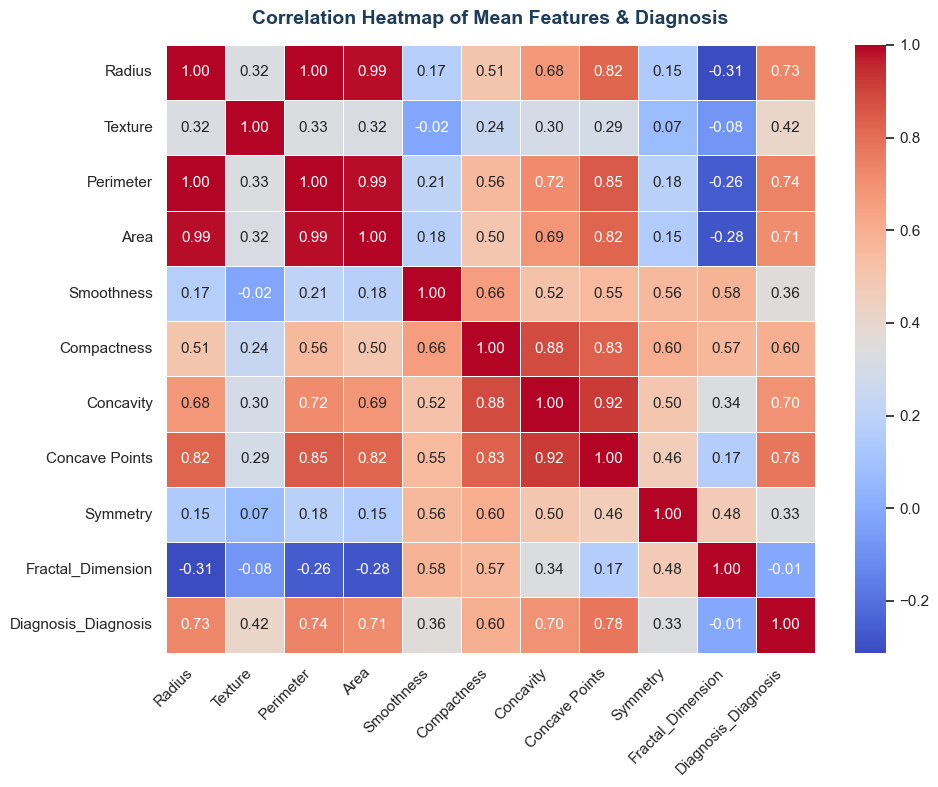

In [4]:
# 2. Correlation Heatmap (Mean columns)
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})
mean_cols = [col for col in df.columns if '_mean' in col] + ['diagnosis_encoded']
corr_matrix = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
clean_labels = [col.replace('_mean', '').title() for col in mean_cols]
clean_labels = [col.replace('Encoded', 'Diagnosis') for col in clean_labels]
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5,
            xticklabels=clean_labels, yticklabels=clean_labels)
plt.title("Correlation Heatmap of Mean Features & Diagnosis", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 4: Mathematical Primer: The Sigmoid Function
Logistic regression maps real-valued numbers into probabilities using the **Sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z = w^T x + b$ represents the linear combination of inputs (logits). The output $\sigma(z)$ lies strictly between $0$ and $1$. Below, we plot the sigmoid curve.


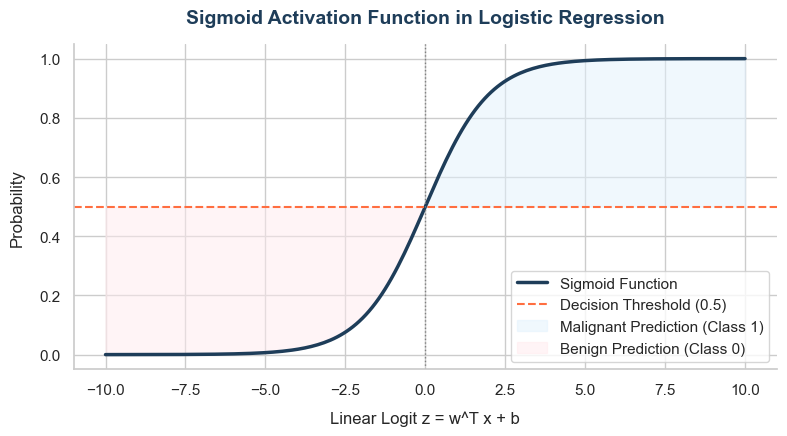

In [5]:
z = np.linspace(-10, 10, 200)
s = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4.5))
plt.plot(z, s, color=PRIMARY_COLOR, linewidth=2.5, label='Sigmoid Function')
plt.axhline(0.5, color=SECONDARY_COLOR, linestyle='--', linewidth=1.5, label='Decision Threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.fill_between(z, 0.5, s, where=(z >= 0), color='#e3f2fd', alpha=0.5, label='Malignant Prediction (Class 1)')
plt.fill_between(z, 0.5, s, where=(z < 0), color='#ffebee', alpha=0.5, label='Benign Prediction (Class 0)')
plt.title("Sigmoid Activation Function in Logistic Regression", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("Linear Logit z = w^T x + b", labelpad=10)
plt.ylabel("Probability", labelpad=10)
plt.legend(loc='lower right', frameon=True)
plt.ylim(-0.05, 1.05)
sns.despine()
plt.tight_layout()
plt.show()


## Step 5: Data Split & Leakage Prevention
We extract the features and target. To prevent data leakage, we separate the data into train and test groups *before* scaling. We drop target-related labels from the feature set.


In [6]:
# Drop ID, original text target, and the encoded target from features to prevent leakage!
X = df.drop(columns=['id', 'diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']

# Stratified Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")


Training set shape: (455, 30)
Testing set shape:  (114, 30)


## Step 6: Model Pipeline Training
To ensure scaling parameters computed on `X_train` are seamlessly applied to `X_test`, we encapsulate `StandardScaler` and `LogisticRegression` within a scikit-learn `Pipeline` object.


In [7]:
# Define the modeling pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=10000))
])

# Train the pipeline on the training subset
pipeline.fit(X_train, y_train)
print("Model pipeline successfully trained!")


Model pipeline successfully trained!


## Step 7: Model Evaluation
We evaluate our classifier on the test set using various metrics. We plot the **Confusion Matrix**, **ROC Curve**, and **Precision-Recall Curve**.


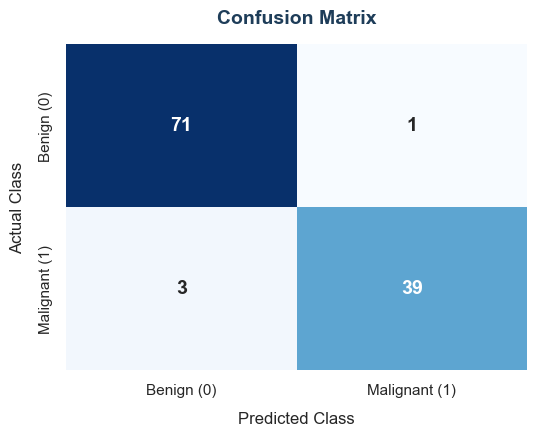

In [8]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title("Confusion Matrix", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("Predicted Class", labelpad=10)
plt.ylabel("Actual Class", labelpad=10)
plt.tight_layout()
plt.show()


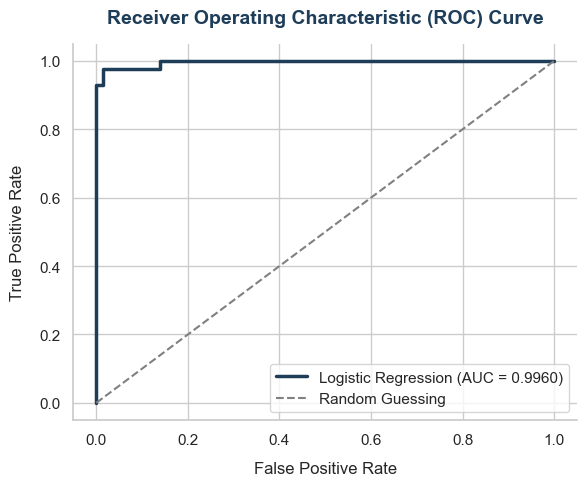

In [9]:
# 2. ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color=PRIMARY_COLOR, linewidth=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Guessing')
plt.title("Receiver Operating Characteristic (ROC) Curve", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("False Positive Rate", labelpad=10)
plt.ylabel("True Positive Rate", labelpad=10)
plt.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()


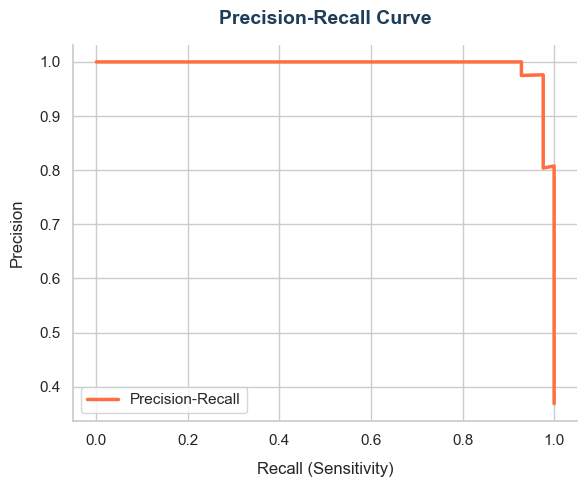

In [10]:
# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, color=SECONDARY_COLOR, linewidth=2.5, label='Precision-Recall')
plt.title("Precision-Recall Curve", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("Recall (Sensitivity)", labelpad=10)
plt.ylabel("Precision", labelpad=10)
plt.legend(loc='lower left')
sns.despine()
plt.tight_layout()
plt.show()


In [11]:
# 4. Print Summary Stats
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## Step 8: Model Interpretation
Since we standardized the features, the model's coefficients reflect feature importance directly. A positive coefficient indicates a feature that increases the probability of malignancy, while a negative coefficient indicates a feature associated with benign cases.


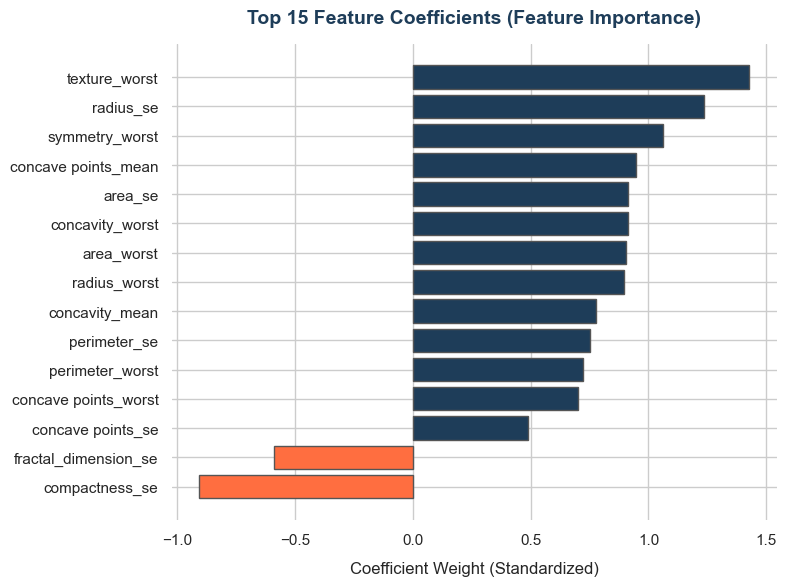

In [12]:
model = pipeline.named_steps['classifier']
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0],
    'AbsoluteWeight': np.abs(model.coef_[0])
}).sort_values(by='AbsoluteWeight', ascending=False)

plt.figure(figsize=(8, 6))
top_15 = coef_df.head(15).sort_values(by='Coefficient', ascending=True)
colors = [PRIMARY_COLOR if val > 0 else SECONDARY_COLOR for val in top_15['Coefficient']]
plt.barh(top_15['Feature'], top_15['Coefficient'], color=colors, edgecolor='#555555')
plt.title("Top 15 Feature Coefficients (Feature Importance)", weight='bold', pad=15, color=PRIMARY_COLOR)
plt.xlabel("Coefficient Weight (Standardized)", labelpad=10)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## Step 9: Save Pipeline & Model
Finally, we dump our trained pipeline to `../models/` so it can be re-loaded for production inference.


In [13]:
os.makedirs('../models', exist_ok=True)
joblib.dump(pipeline, '../models/logistic_regression_model.pkl')
print("Trained model pipeline serialized to ../models/logistic_regression_model.pkl")


Trained model pipeline serialized to ../models/logistic_regression_model.pkl